In [15]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

path = Path("projected_buildings_stats_ch.geojson")  # adjust if needed

with path.open("r", encoding="utf-8") as f:
    data = json.load(f)

features = data["features"]

# flatten properties
df = pd.DataFrame([feat.get("properties", {}) for feat in features])

# make sure numeric
for col in ["gastw", "h_vol_area", "gkat"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# height per floor
df["h_per_floor"] = df["h_vol_area"] / df["gastw"]

# keep only reasonable values (e.g. between 1 m and 5 m per floor)
df_valid = df[df["h_per_floor"].between(2.3, 20.0)]
# df_valid = all
len(df_valid)


15566

In [1]:
def print_height_stats(series, label="all"):
    s = series.dropna().sort_values()
    if s.empty:
        print(f"{label}: no data")
        return

    q = s.quantile([0.05, 0.10, 0.20, 0.25, 0.5, 0.75, 0.80, 0.90, 0.95])

    print(f"\nStats for {label} (n = {len(s)}):")
    print(f"  median:        {q.loc[0.50]:.3f} m/floor")
    print(f"  25% quartile:  {q.loc[0.25]:.3f} m/floor")
    print(f"  75% quartile:  {q.loc[0.75]:.3f} m/floor")
    print(f"  lower 20%:     <= {q.loc[0.20]:.3f} m/floor")
    print(f"  upper 20%:     >= {q.loc[0.80]:.3f} m/floor")
    print(f"  lower 10%:     <= {q.loc[0.10]:.3f} m/floor")
    print(f"  upper 10%:     >= {q.loc[0.90]:.3f} m/floor")
    print(f"  lower 5%:      <= {q.loc[0.05]:.3f} m/floor")
    print(f"  upper 5%:      >= {q.loc[0.95]:.3f} m/floor")

print_height_stats(df_valid["h_per_floor"], label="all gkat")


NameError: name 'df_valid' is not defined

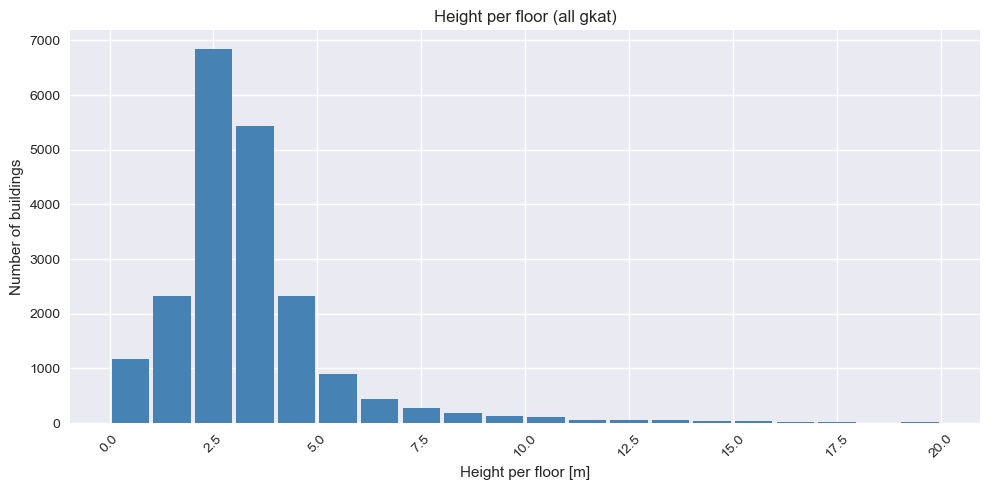

In [35]:
bin_width = 1  # 10 cm
min_h = df_valid["h_per_floor"].min()
max_h = df_valid["h_per_floor"].max()

bins = np.arange(np.floor(min_h / bin_width) * bin_width,
                 np.ceil(max_h / bin_width) * bin_width + bin_width,
                 bin_width)

counts, edges = np.histogram(df_valid["h_per_floor"], bins=bins)
centers = edges[:-1] + bin_width / 2

plt.figure(figsize=(10, 5))
plt.bar(centers, counts, width=bin_width * 0.9, align="center", color="steelblue")
plt.xlabel("Height per floor [m]")
plt.ylabel("Number of buildings")
plt.title("Height per floor (all gkat)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Stats for gkat=1020.0 (Gebäude mit ausschliesslicher Wohnnutzung) (n = 14599):
  median:        2.952 m/floor
  25% quartile:  2.297 m/floor
  75% quartile:  3.756 m/floor
  lower 20%:     <= 2.074 m/floor
  upper 20%:     >= 4.000 m/floor
  lower 10%:     <= 1.345 m/floor
  upper 10%:     >= 4.798 m/floor
  lower 5%:      <= 0.875 m/floor
  upper 5%:      >= 5.903 m/floor


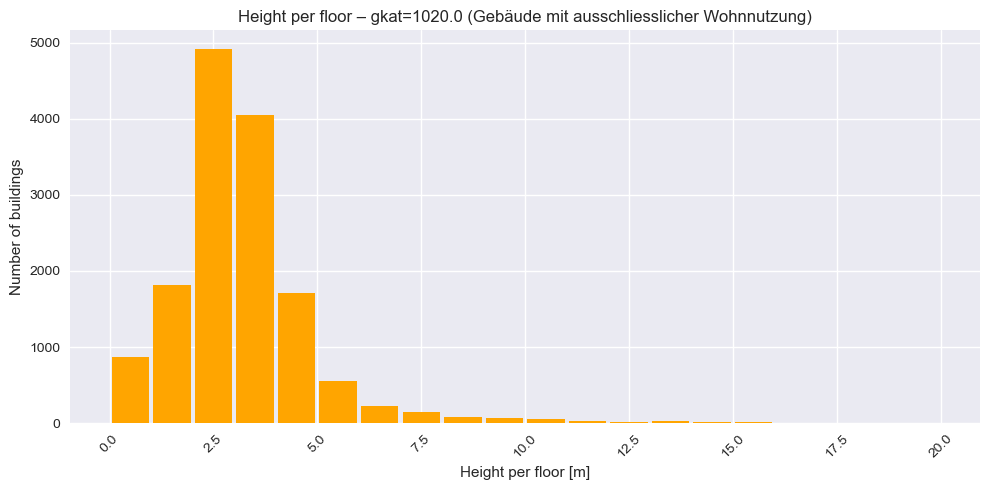


Stats for gkat=1030.0 (Andere Wohngebäude (Wohngebäude mit Nebennutzung)) (n = 992):
  median:        2.900 m/floor
  25% quartile:  2.271 m/floor
  75% quartile:  3.667 m/floor
  lower 20%:     <= 2.061 m/floor
  upper 20%:     >= 3.863 m/floor
  lower 10%:     <= 1.117 m/floor
  upper 10%:     >= 4.637 m/floor
  lower 5%:      <= 0.563 m/floor
  upper 5%:      >= 5.536 m/floor


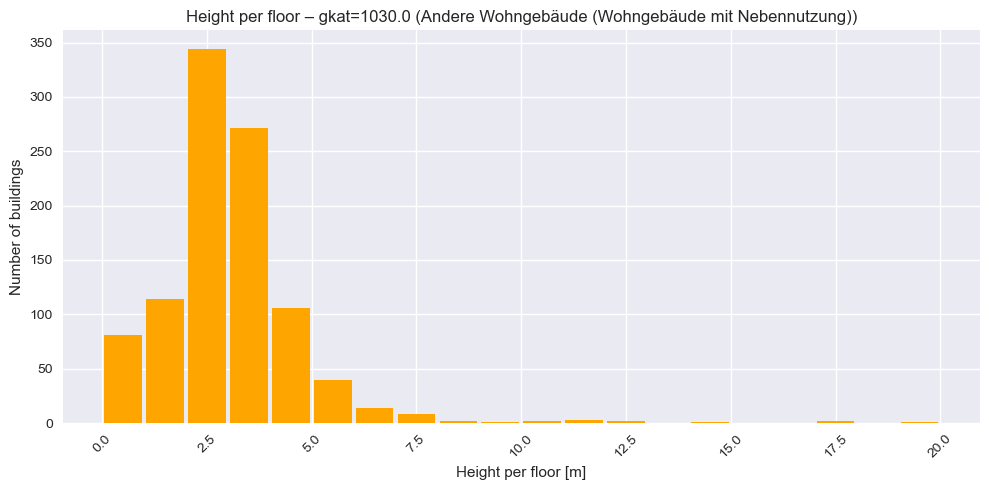


Stats for gkat=1040.0 (Gebäude mit teilweiser Wohnnutzung) (n = 328):
  median:        2.870 m/floor
  25% quartile:  2.229 m/floor
  75% quartile:  3.761 m/floor
  lower 20%:     <= 1.909 m/floor
  upper 20%:     >= 4.057 m/floor
  lower 10%:     <= 1.001 m/floor
  upper 10%:     >= 4.801 m/floor
  lower 5%:      <= 0.680 m/floor
  upper 5%:      >= 6.130 m/floor


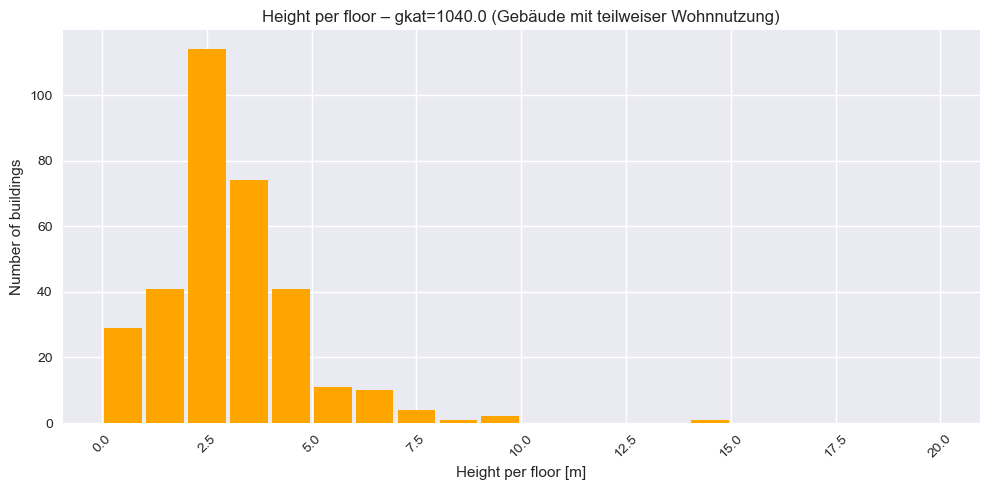


Stats for gkat=1060.0 (Gebäude ohne Wohnnutzung) (n = 4225):
  median:        3.112 m/floor
  25% quartile:  2.500 m/floor
  75% quartile:  4.741 m/floor
  lower 20%:     <= 2.333 m/floor
  upper 20%:     >= 5.343 m/floor
  lower 10%:     <= 1.786 m/floor
  upper 10%:     >= 7.688 m/floor
  lower 5%:      <= 1.000 m/floor
  upper 5%:      >= 10.153 m/floor


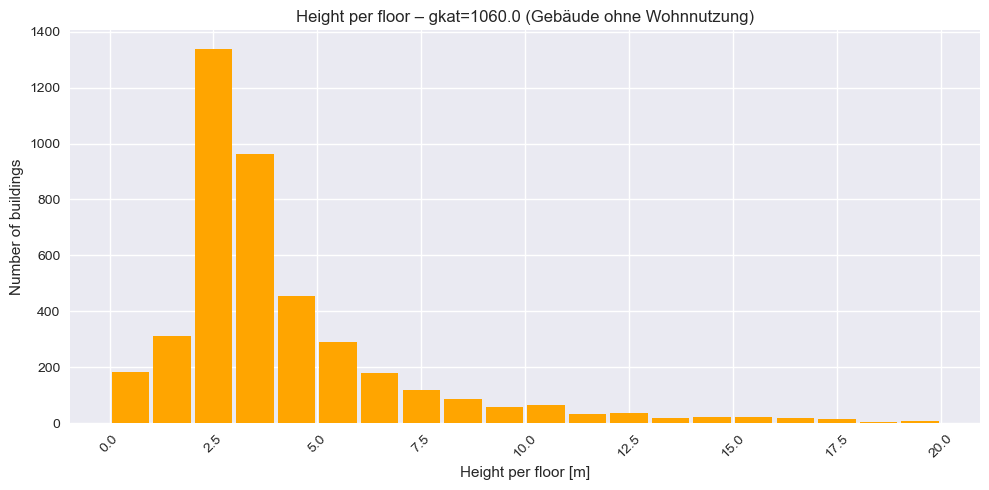


Stats for gkat=1080.0 (Sonderbau) (n = 304):
  median:        2.858 m/floor
  25% quartile:  2.339 m/floor
  75% quartile:  3.629 m/floor
  lower 20%:     <= 2.138 m/floor
  upper 20%:     >= 3.861 m/floor
  lower 10%:     <= 1.689 m/floor
  upper 10%:     >= 6.140 m/floor
  lower 5%:      <= 1.139 m/floor
  upper 5%:      >= 8.250 m/floor


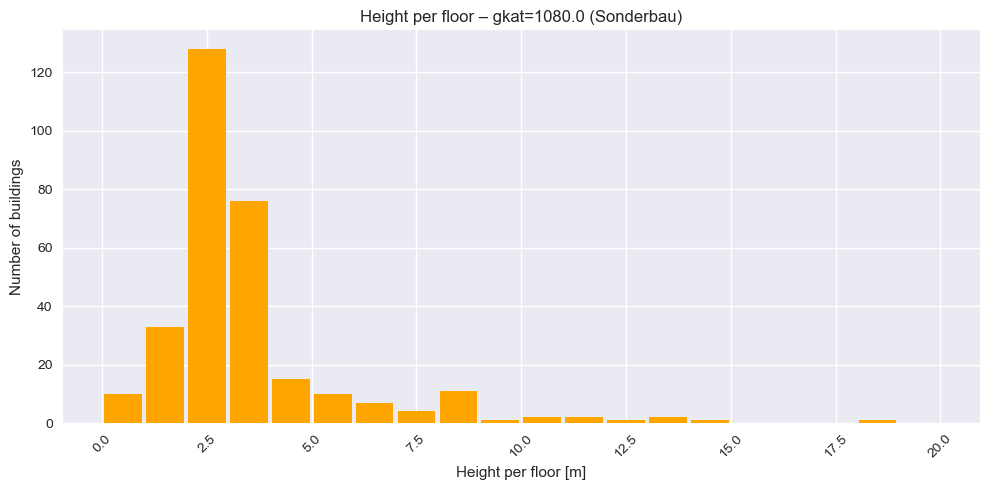

In [36]:
# if you have gkat_text column, keep it
has_gkat_text = "gkat_text" in df_valid.columns

for gkat_val, group in df_valid.groupby("gkat"):
    label = f"gkat={gkat_val}"
    if has_gkat_text:
        text = group["gkat_text"].iloc[0]
        if pd.notna(text):
            label += f" ({text})"

    # print stats
    print_height_stats(group["h_per_floor"], label=label)

    # histogram per gkat
    s = group["h_per_floor"].dropna()
    if s.empty:
        continue

    counts, edges = np.histogram(s, bins=bins)
    centers = edges[:-1] + bin_width / 2

    plt.figure(figsize=(10, 5))
    plt.bar(centers, counts, width=bin_width * 0.9, align="center", color="orange")
    plt.xlabel("Height per floor [m]")
    plt.ylabel("Number of buildings")
    plt.title(f"Height per floor – {label}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


testing

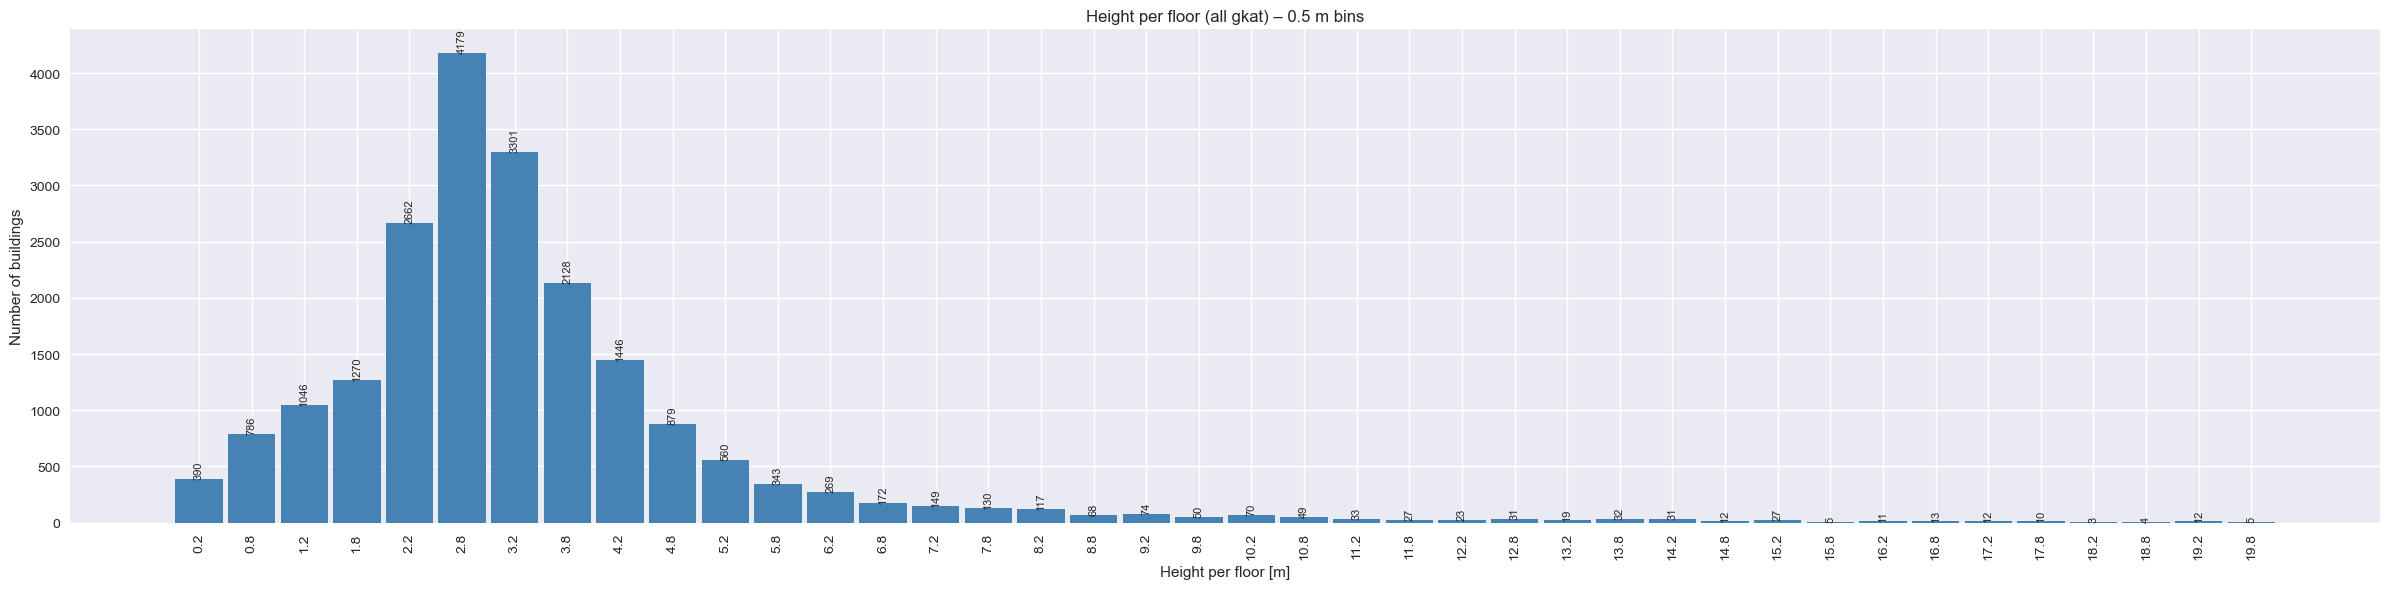

In [37]:
import numpy as np
import matplotlib.pyplot as plt

s = df_valid["h_per_floor"].dropna()

bin_width = 0.50  # 50 cm

min_h = s.min()
max_h = s.max()

bins = np.arange(np.floor(min_h / bin_width) * bin_width,
                 np.ceil(max_h / bin_width) * bin_width + bin_width,
                 bin_width)

counts, edges = np.histogram(s, bins=bins)
centers = edges[:-1] + bin_width / 2

plt.figure(figsize=(max(12, len(centers) * 0.6), 6))  # stretch with number of bins
bars = plt.bar(centers, counts, width=bin_width * 0.9, align="center", color="steelblue")

plt.xlabel("Height per floor [m]")
plt.ylabel("Number of buildings")
plt.title("Height per floor (all gkat) – 0.5 m bins")

# label each bar with its count (only if > 0 to avoid clutter)
for c, x in zip(counts, centers):
    if c > 0:
        plt.text(x, c, str(c), ha="center", va="bottom", fontsize=8, rotation=90)

plt.xticks(centers, [f"{v:.1f}" for v in centers], rotation=90)
plt.tight_layout()
plt.show()


# Height Statistics (Enriched CH)
The following cells analyze the computed heights and their sources from the `height_statistics_enriched_ch.csv`.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

# Read the recently created CSV containing the stats
csv_path = "height_statistics_enriched_ch.csv"
stats_df = pd.read_csv(csv_path)

# Overview of the actual data
print("Data Overview:")
print(stats_df.info())
stats_df.head()

Data Overview:
<class 'pandas.DataFrame'>
RangeIndex: 46322 entries, 0 to 46321
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   egid              0 non-null      float64
 1   gkat              29189 non-null  float64
 2   height_raw_gvol   20818 non-null  float64
 3   height_raw_gastw  27613 non-null  float64
 4   computed_height   46322 non-null  float64
 5   height_source     46322 non-null  str    
dtypes: float64(5), str(1)
memory usage: 2.1 MB
None


,egid,gkat,height_raw_gvol,height_raw_gastw,computed_height,height_source
0,NaN,1020.0,5.752922,7.5,5.752922,volume_math
1,NaN,1020.0,5.365609,7.5,5.365609,volume_math
2,NaN,1020.0,7.061453,5.0,7.061453,volume_math
3,NaN,1020.0,3.031785,10.0,3.031785,volume_math
4,NaN,1060.0,1.196925,3.0,3.000000,floors_math


C:\Users\st1178102.EDU\AppData\Local\Temp\ipykernel_36496\659989928.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.index, y=source_counts.values, palette="viridis")


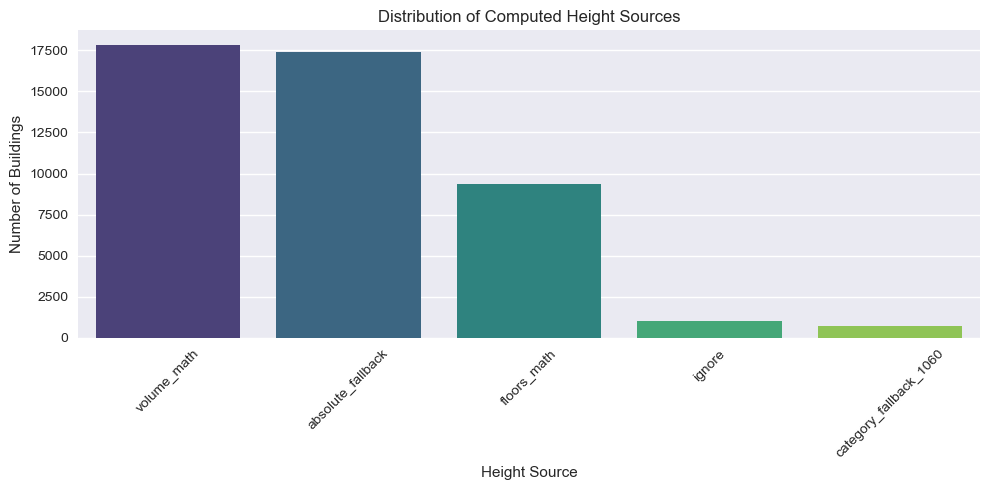

In [4]:
# 1. Plot the Distribution of Height Sources
plt.figure(figsize=(10, 5))
source_counts = stats_df['height_source'].value_counts()
sns.barplot(x=source_counts.index, y=source_counts.values, palette="viridis")

plt.title("Distribution of Computed Height Sources")
plt.xlabel("Height Source")
plt.ylabel("Number of Buildings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

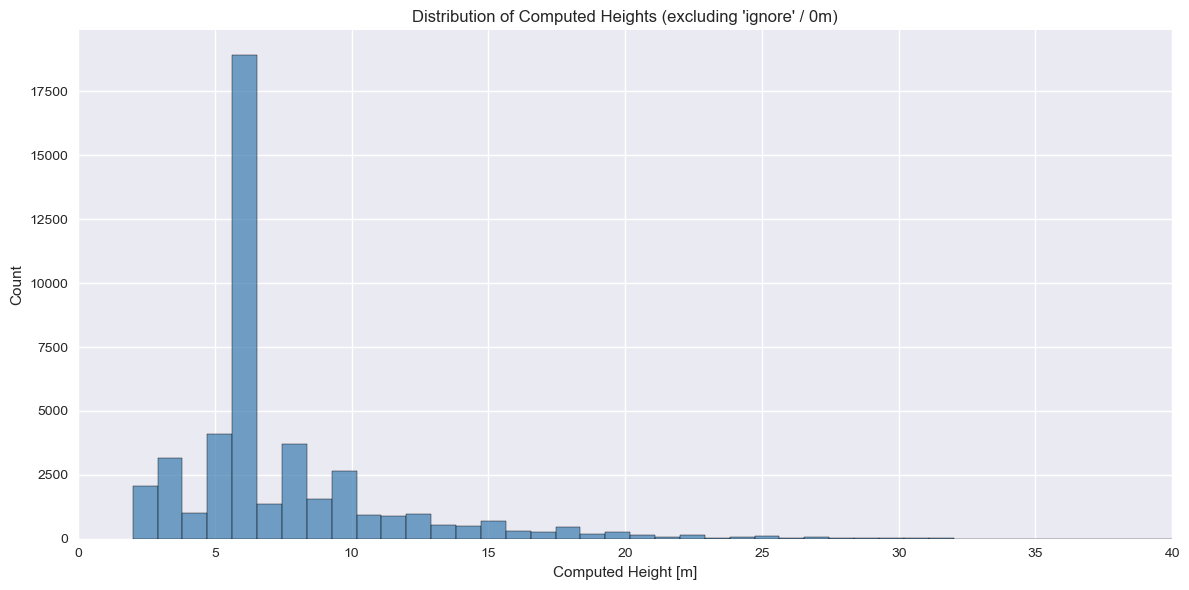

In [5]:
# Exclude 'ignore' features (where height is artificially set to 0 and the object is dropped)
valid_heights = stats_df[stats_df['height_source'] != 'ignore']

# 2. Histogram of Computed Heights
plt.figure(figsize=(12, 6))
sns.histplot(valid_heights['computed_height'], bins=100, kde=False, color="steelblue")
plt.title("Distribution of Computed Heights (excluding 'ignore' / 0m)")
plt.xlabel("Computed Height [m]")
plt.ylabel("Count")

# We limit the X-axis slightly to visualize the bulk of the data without being distorted by rare skyscrapers
plt.xlim(0, max(40, valid_heights['computed_height'].quantile(0.99)))
plt.tight_layout()
plt.show()

C:\Users\st1178102.EDU\AppData\Local\Temp\ipykernel_36496\1717937368.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_heights, x="height_source", y="computed_height", palette="Set2")


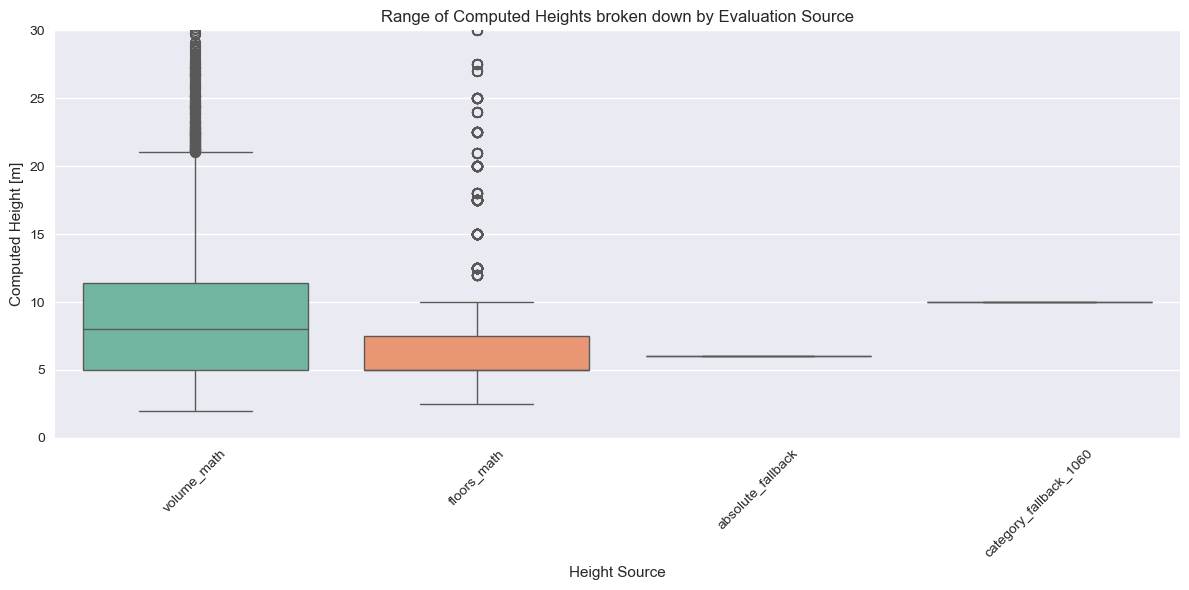

,count,mean,std,min,25%,50%,75%,max
height_source,,,,,,,,
absolute_fallback,17421.0,6.000000,0.000000,6.0,6.0,6.000000,6.000000,6.000000
category_fallback_1060,713.0,10.000000,0.000000,10.0,10.0,10.000000,10.000000,10.000000
floors_math,9346.0,6.970041,4.757418,2.5,5.0,5.000000,7.500000,75.000000
volume_math,17819.0,8.901382,5.545114,2.0,5.0,8.009709,11.423128,92.920824


In [6]:
# 3. Boxplot of distribution relative to their Source type
plt.figure(figsize=(12, 6))
sns.boxplot(data=valid_heights, x="height_source", y="computed_height", palette="Set2")
plt.title("Range of Computed Heights broken down by Evaluation Source")
plt.xlabel("Height Source")
plt.ylabel("Computed Height [m]")
plt.xticks(rotation=45)
plt.ylim(0, 30) # Capped at 30 meters to clearly see the box quartiles 
plt.tight_layout()
plt.show()

# Show tabular breakdown of the descriptions per source
valid_heights.groupby('height_source')['computed_height'].describe()